<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/Week3_Bibit_BoW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup & Install


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from scipy.sparse import save_npz

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [4]:
import pandas as pd

df_clean = pd.read_csv('/content/drive/MyDrive/NLP/bibit_reviews_cleaned.csv')

print(f'Shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns')
print(f'Columns: {list(df_clean.columns)}')
df_clean.head()

Shape: 36,237 rows x 8 columns
Columns: ['content', 'score', 'at', 'thumbsUpCount', 'replyContent', 'sentiment', 'final_text', 'tokens_final']


,content,score,at,thumbsUpCount,replyContent,sentiment,final_text,tokens_final
0,okelah buat nabung,5,2026-03-30 01:40:09,0,Terima kasih telah memilih Bibit sebagai platf...,positive,oke nabung,"['oke', 'nabung']"
1,Apk rekomendasi untuk pemula yang ingin tau te...,5,2026-03-30 01:38:55,0,Terima kasih telah memilih Bibit sebagai platf...,positive,rekomendasi mula tau dunia,"['rekomendasi', 'mula', 'tau', 'dunia']"
2,good,5,2026-03-29 17:29:32,0,Terima kasih telah memilih Bibit sebagai platf...,positive,good,['good']
3,manager investasinya bodo nitip duit malah min...,1,2026-03-29 12:43:12,0,"Hai kak, fluktuasi pasar itu wajar dalam inves...",negative,manager investasi bodo nitip duit minus gue ma...,"['manager', 'investasi', 'bodo', 'nitip', 'dui..."
4,Aplikasinya bagus banget,4,2026-03-29 12:41:25,0,Terima kasih atas kepercayaan & kesetiaan kaka...,positive,aplikasi bagus banget,"['aplikasi', 'bagus', 'banget']"


In [5]:
null_count = df_clean['final_text'].isnull().sum()
empty_count = (df_clean['final_text'].str.strip() == '').sum()

print(f'Null values    : {null_count}')
print(f'Empty values   : {empty_count}')

df_clean = df_clean.dropna(subset=['final_text'])
df_clean = df_clean[df_clean['final_text'].str.strip() != '']

df_clean.reset_index(drop=True, inplace=True)

print(f'\nTotal rows after removal: {len(df_clean):,}')

Null values    : 0
Empty values   : 0

Total rows after removal: 36,237


Statistik Jumlah Kata:
count    36237.00
mean         5.69
std          5.32
min          1.00
25%          2.00
50%          4.00
75%          7.00
max         59.00
Name: length, dtype: float64


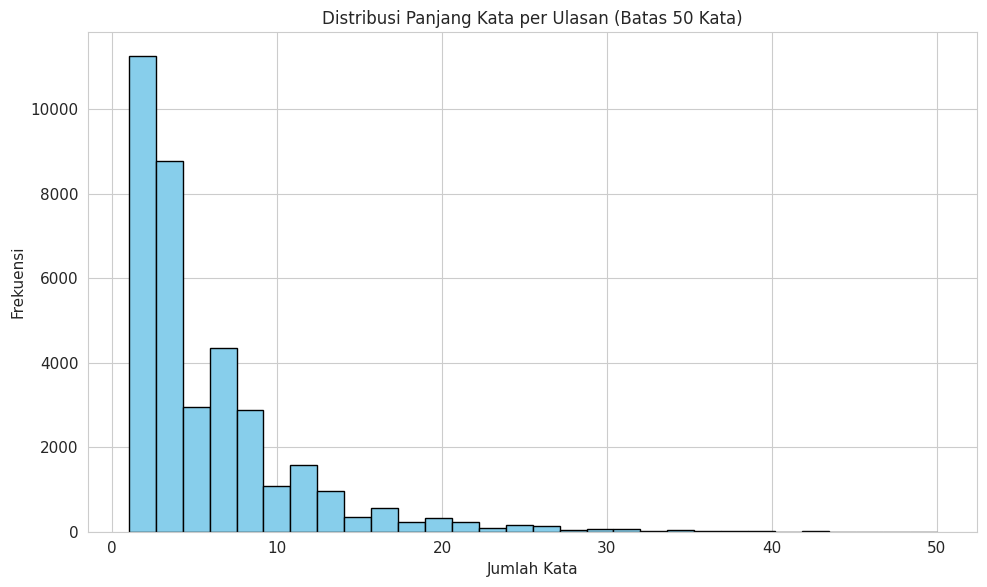

In [6]:
df_clean['length'] = df_clean['final_text'].str.split().str.len()

print("Statistik Jumlah Kata:")
print(df_clean['length'].describe().round(2))

fig, ax = plt.subplots(figsize=(10, 6))
df_clean['length'].clip(upper=50).plot(kind='hist', bins=30, ax=ax, color='skyblue', edgecolor='black')

ax.set_title('Distribusi Panjang Kata per Ulasan (Batas 50 Kata)', fontsize=12)
ax.set_xlabel('Jumlah Kata')
ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('word_distribution.png')

In [7]:
print("Contoh Ulasan Hasil Pembersihan:")
print("-" * 50)

samples = df_clean[['final_text', 'sentiment']].sample(5, random_state=42)

for i, row in samples.iterrows():
    print(f"Label: {row['sentiment']}")
    print(f"Teks : {row['final_text'][:120]}...")
    print("-" * 30)

Contoh Ulasan Hasil Pembersihan:
--------------------------------------------------
Label: positive
Teks : milik fitur bantu mula awam terima kasih...
------------------------------
Label: positive
Teks : terpercaya...
------------------------------
Label: negative
Teks : wow kali wd untung jual itung rugi kena fee rekom dah...
------------------------------
Label: positive
Teks : mudah terpercaya...
------------------------------
Label: positive
Teks : min coba ubah data bank ganti...
------------------------------


In [8]:
cv_model = CountVectorizer(
    analyzer='word',
    token_pattern=r'\b\w+\b',
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 1)
)

X_bow = cv_model.fit_transform(df_clean['final_text'])

total_docs, total_vocab = X_bow.shape
nnz = X_bow.nnz
sparsity = (1 - nnz / (total_docs * total_vocab)) * 100

print(f"Dimensi Matrix BoW : {X_bow.shape}")
print(f"Jumlah Dokumen      : {total_docs:,}")
print(f"Jumlah Fitur/Kata   : {total_vocab:,}")
print(f"Non-zero elements   : {nnz:,}")
print(f"Tingkat Sparsitas   : {sparsity:.4f}%")

Dimensi Matrix BoW : (36237, 3805)
Jumlah Dokumen      : 36,237
Jumlah Fitur/Kata   : 3,805
Non-zero elements   : 191,348
Tingkat Sparsitas   : 99.8612%


In [9]:
features = cv_model.get_feature_names_out()
vocab_size = len(features)

print(f"Ukuran Kosakata: {vocab_size:,}")

print("\n20 Kata Pertama:")
print(features[:20])

print("\n20 Kata Terakhir:")
print(features[-20:])

Ukuran Kosakata: 3,805

20 Kata Pertama:
['aa' 'aamiin' 'aap' 'ab' 'abad' 'abal' 'abang' 'abin' 'abis' 'about'
 'acak' 'acc' 'account' 'aceh' 'acl' 'aco' 'acount' 'action' 'acung' 'ada']

20 Kata Terakhir:
['yess' 'yesss' 'yey' 'yg' 'yok' 'you' 'your' 'youtube' 'youtuber' 'yra'
 'yt' 'yth' 'yuk' 'yukburuan' 'yukcobainvestasi' 'yusranbibit' 'zaman'
 'zero' 'zonk' 'zy']


In [10]:
word_counts = np.asarray(X_bow.sum(axis=0)).ravel()

df_word_freq = pd.DataFrame({
    'word': features,
    'total': word_counts
})

df_word_freq = df_word_freq.sort_values(by='total', ascending=False).reset_index(drop=True)

print("Daftar 30 Kata Terpopuler (BoW):")
print(df_word_freq.head(30))

Daftar 30 Kata Terpopuler (BoW):
         word  total
0        kode   5226
1       bagus   4291
2        mula   4095
3       mudah   3937
4       masuk   3760
5       pakai   3709
6      banget   3104
7    cashback   2851
8        moga   2404
9        ajar   2288
10       dana   2060
11     mantap   2036
12       coba   1972
13      bantu   1962
14       uang   1833
15  investasi   1691
16      keren   1682
17       cair   1646
18      kasih   1612
19       jual   1604
20     daftar   1515
21       buka   1488
22    referal   1487
23      tarik   1386
24       beli   1305
25     untung   1303
26       kalo   1299
27   aplikasi   1291
28     nabung   1287
29   referral   1198


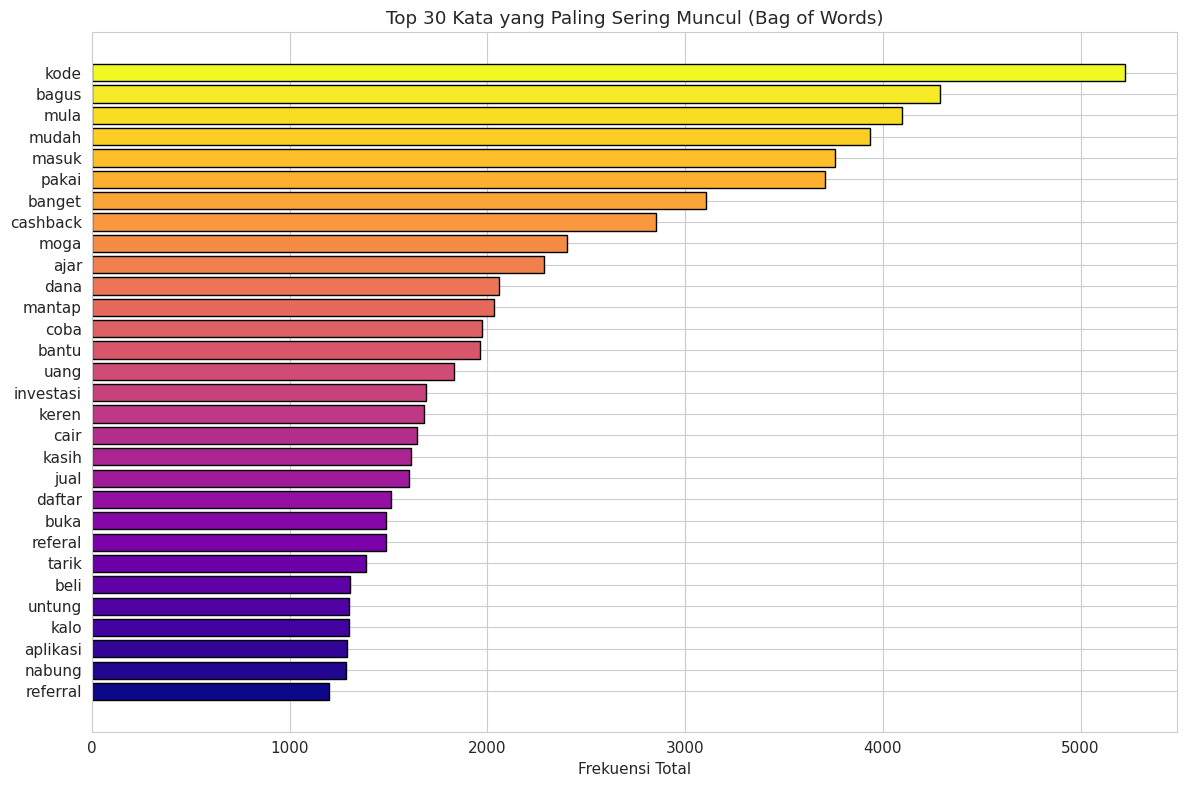

In [11]:
top_n = 30
top_terms = df_word_freq.head(top_n)

fig, ax = plt.subplots(figsize=(12, 8))
y_pos = np.arange(len(top_terms))

ax.barh(y_pos, top_terms['total'][::-1], color=plt.cm.plasma(np.linspace(0, 1, top_n)), edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(top_terms['word'][::-1])
ax.set_xlabel('Frekuensi Total')
ax.set_title(f'Top {top_n} Kata yang Paling Sering Muncul (Bag of Words)')

plt.tight_layout()
plt.savefig('top_30_words_bow.png')

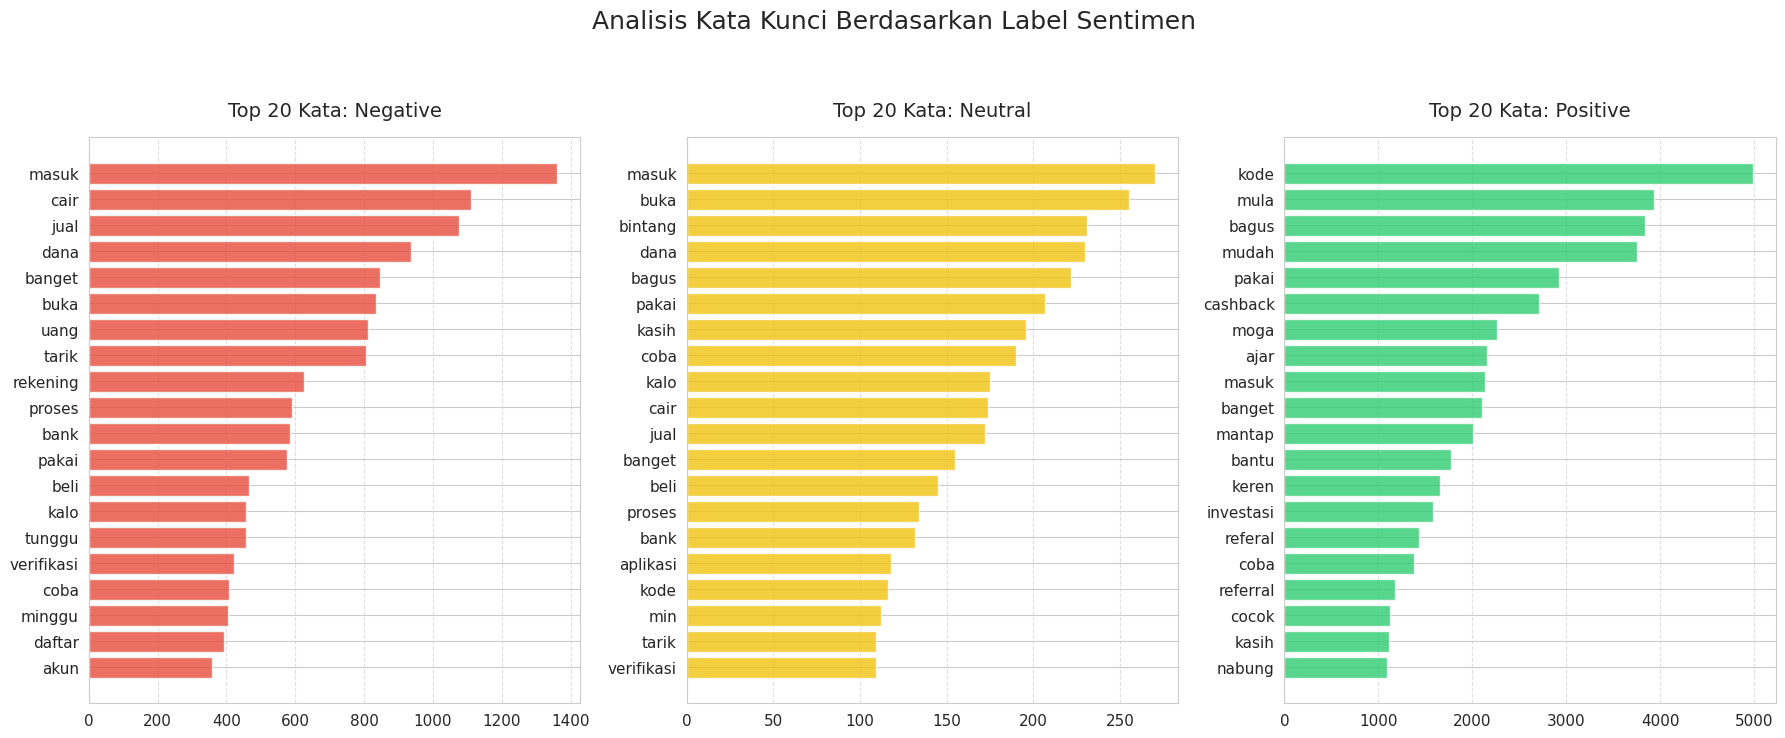

In [12]:
kategori_sentimen = sorted(df_clean['sentiment'].unique())
jumlah_kategori = len(kategori_sentimen)

fig, ax_list = plt.subplots(1, jumlah_kategori, figsize=(6 * jumlah_kategori, 7))

warna_map = {
    'negative': '#e74c3c',
    'neutral': '#f1c40f',
    'positive': '#2ecc71'
}

for i, label in enumerate(kategori_sentimen):
    idx_sentimen = df_clean[df_clean['sentiment'] == label].index
    matriks_subset = X_bow[idx_sentimen]

    frekuensi_kata = np.asarray(matriks_subset.sum(axis=0)).ravel()
    top_20_idx = frekuensi_kata.argsort()[-20:]

    kata_populer = features[top_20_idx]
    skor_populer = frekuensi_kata[top_20_idx]

    warna = warna_map.get(label, 'skyblue')
    ax_list[i].barh(kata_populer, skor_populer, color=warna, alpha=0.8)
    ax_list[i].set_title(f'Top 20 Kata: {label.capitalize()}', fontsize=14, pad=15)
    ax_list[i].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('Analisis Kata Kunci Berdasarkan Label Sentimen', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [13]:
total_skor_kata = np.asarray(X_bow.sum(axis=0)).flatten()
indeks_teratas = total_skor_kata.argsort()[-20:][::-1]
kata_teratas = features[indeks_teratas]

df_preview_bow = pd.DataFrame(
    X_bow[:10, indeks_teratas].toarray(),
    columns=kata_teratas
)

print("Cuplikan Matriks BoW (10 baris pertama x 20 kata terpopuler):")
df_preview_bow

Cuplikan Matriks BoW (10 baris pertama x 20 kata terpopuler):


,kode,bagus,mula,mudah,masuk,pakai,banget,cashback,moga,ajar,dana,mantap,coba,bantu,uang,investasi,keren,cair,kasih,jual
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0
4,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
